# Linear Regression -- End to End with the Advertising Dataset

Linear regression is one of the most fundamental algorithms in machine learning, and arguably the best starting point for anyone learning predictive modelling. The idea is simple: given some input features, can we draw a straight line (or a hyperplane, in higher dimensions) that best predicts a continuous output?

In this notebook we will work through the entire pipeline -- from loading and understanding the data, through exploratory analysis and visualisation, all the way to building, evaluating, and interpreting a linear regression model.

**Dataset:** The classic *Advertising* dataset, which records the money spent on TV, Radio, and Newspaper advertising along with the resulting Sales figures (in thousands of units) for 200 markets.

**What we will cover:**
1. Loading and inspecting the data
2. Descriptive statistics
3. Exploratory Data Analysis (EDA) and visualisation
4. Checking assumptions
5. Preparing data for modelling
6. Building the model (simple and multiple linear regression)
7. Evaluating the model
8. Residual analysis
9. Interpreting the coefficients

## 1. Import Libraries

In [1]:
! pip install seaborn scikit-learn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached matplotlib-3.10.8-cp311-cp311-macosx_11_0_arm64.whl.metadata (52 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
  Using cached contourpy-1.3.3-cp311-cp311-macosx_11_0_arm64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.62.1-cp311-cp311-macosx_10_9_universal2.whl.metadata (117 kB)
  Using cached kiwisolver-1.5.0-cp311-cp311-macosx_11_0_arm64.whl.metadata (5.1 kB)
  Using cached pillow-12.2.0-cp311-cp311-macosx_11_0_arm64.whl.metadata (8.8 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.1/8.1 MB 25.4 MB/s  0:00:00 eta 0:00:01
Using cached joblib-1.5.3-py3-none-any.whl (309 kB)
Using cached matplotlib-3.10.8-cp311-cp311-macosx_11_0_arm64

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from scipy import stats

import warnings
warnings.filterwarnings('ignore')

# visual defaults
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

## 2. Load the Dataset

The Advertising dataset is publicly available. We will load it directly from a URL so there is nothing to download manually. Each row corresponds to a different market and records three advertising budgets (in thousands of dollars) alongside the resulting sales (in thousands of units).

In [7]:
# try multiple known sources for the Advertising dataset
urls = [
    "https://www.statlearning.com/s/Advertising.csv",
    "https://raw.githubusercontent.com/jbrownlee/Datasets/master/advertising.csv",
]

df = None
for u in urls:
    try:
        df = pd.read_csv(u)
        print(f"Loaded from: {u}")
        break
    except Exception:
        continue

df.head()

Loaded from: https://www.statlearning.com/s/Advertising.csv


,Unnamed: 0,TV,radio,newspaper,sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


In [8]:
# drop the unnamed index column if present
if 'Unnamed: 0' in df.columns:
    df.drop('Unnamed: 0', axis=1, inplace=True)

# standardise column names to a consistent format
df.columns = [c.strip() for c in df.columns]
rename_map = {c: c.upper() if c.upper() == 'TV' else c.title() for c in df.columns}
df.rename(columns=rename_map, inplace=True)

print(f"Shape of the dataset: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"Columns: {list(df.columns)}\n")
df.head(10)

Shape of the dataset: 200 rows, 4 columns
Columns: ['TV', 'Radio', 'Newspaper', 'Sales']



,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9
5,8.7,48.9,75.0,7.2
6,57.5,32.8,23.5,11.8
7,120.2,19.6,11.6,13.2
8,8.6,2.1,1.0,4.8
9,199.8,2.6,21.2,10.6


## 3. Data Description

Before doing anything else, let us understand the structure and quality of the data. We need to check data types, missing values, and basic summary statistics. This step is often underestimated but it can save a lot of debugging later.

In [9]:
# data types and non-null counts
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


In [10]:
# check for missing values
print("Missing values per column:")
print(df.isnull().sum())
print(f"\nTotal missing values: {df.isnull().sum().sum()}")

Missing values per column:
TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64

Total missing values: 0


In [11]:
# descriptive statistics
df.describe().round(2)

,TV,Radio,Newspaper,Sales
count,200.00,200.00,200.00,200.00
mean,147.04,23.26,30.55,14.02
std,85.85,14.85,21.78,5.22
min,0.70,0.00,0.30,1.60
25%,74.38,9.98,12.75,10.38
50%,149.75,22.90,25.75,12.90
75%,218.82,36.52,45.10,17.40
max,296.40,49.60,114.00,27.00


**Quick observations from the summary:**

- All four columns are numeric (float64) -- no encoding needed.
- There are no missing values, which is convenient.
- TV budgets vary a lot (0.7 to 296.4), while Newspaper budgets are more modest on average.
- Sales range from about 1.6 to 27 thousand units.

## 4. Exploratory Data Analysis (EDA) and Visualisation

Now we dig deeper. The goal here is to understand the distribution of each variable individually, and then look at the relationships between the features and the target variable (Sales).

### 4.1 Distribution of each variable

Histograms with KDE overlays give us a quick feel for the shape, centre, and spread of each column.

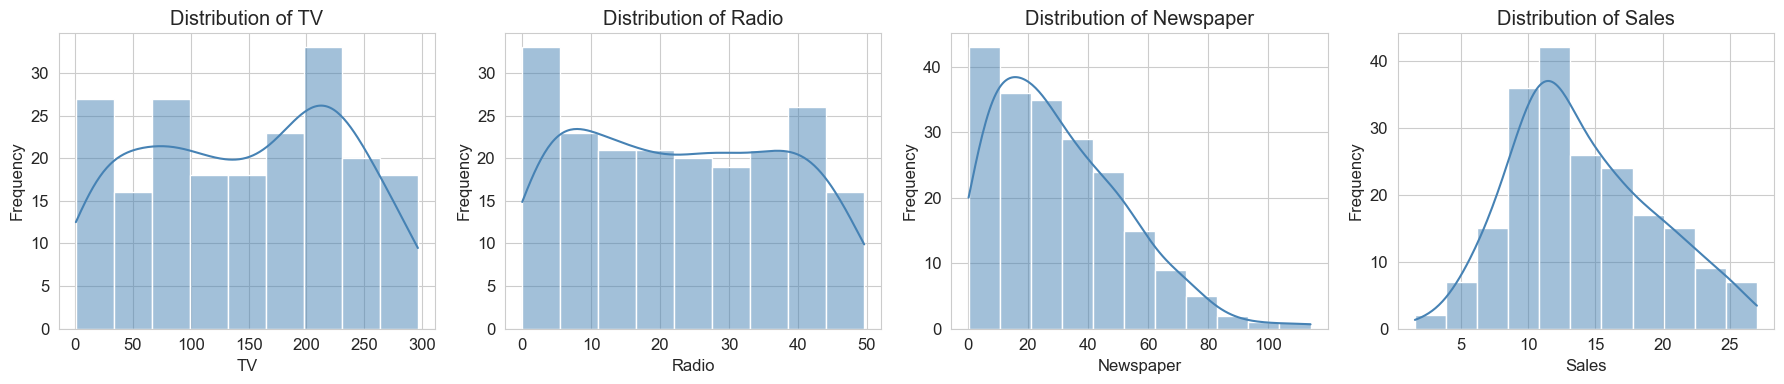

In [13]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

for i, col in enumerate(df.columns):
    sns.histplot(df[col], kde=True, ax=axes[i], color='steelblue', edgecolor='white')
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

### 4.2 Boxplots -- spotting outliers

Boxplots are the fastest way to check for outliers. Any point sitting far outside the whiskers deserves a closer look.

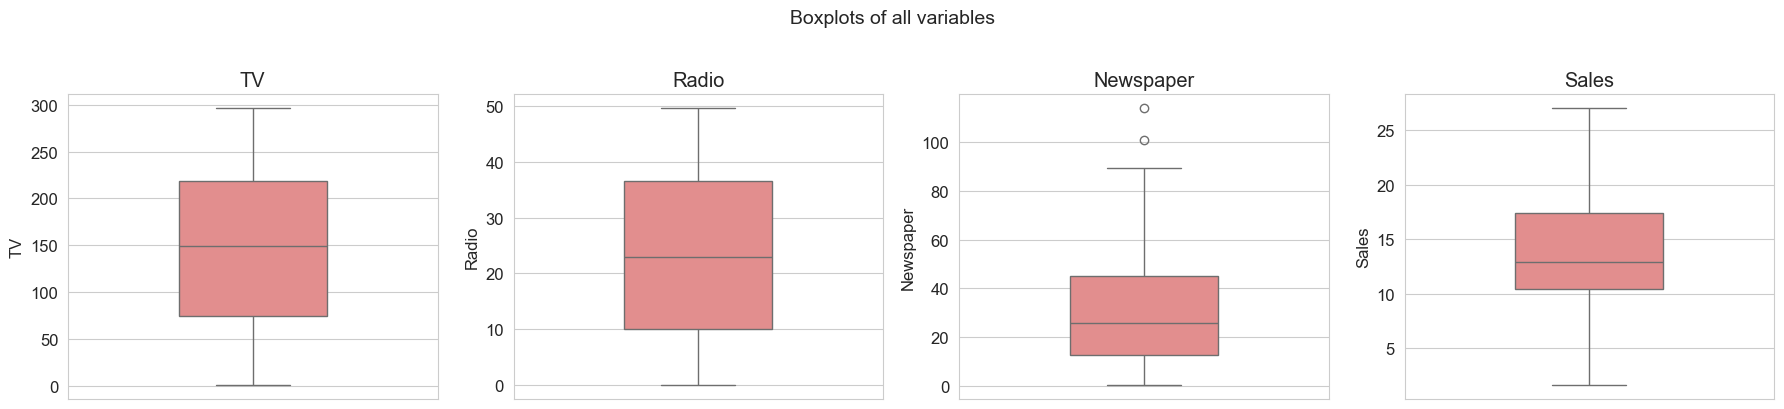

In [12]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

for i, col in enumerate(df.columns):
    sns.boxplot(y=df[col], ax=axes[i], color='lightcoral', width=0.4)
    axes[i].set_title(f'{col}')
    axes[i].set_ylabel(col)

plt.suptitle('Boxplots of all variables', y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

### 4.3 Scatter plots -- feature vs Sales

This is arguably the most important visualisation step. We want to see whether each advertising channel has a linear relationship with Sales, because that is exactly what our model will assume.

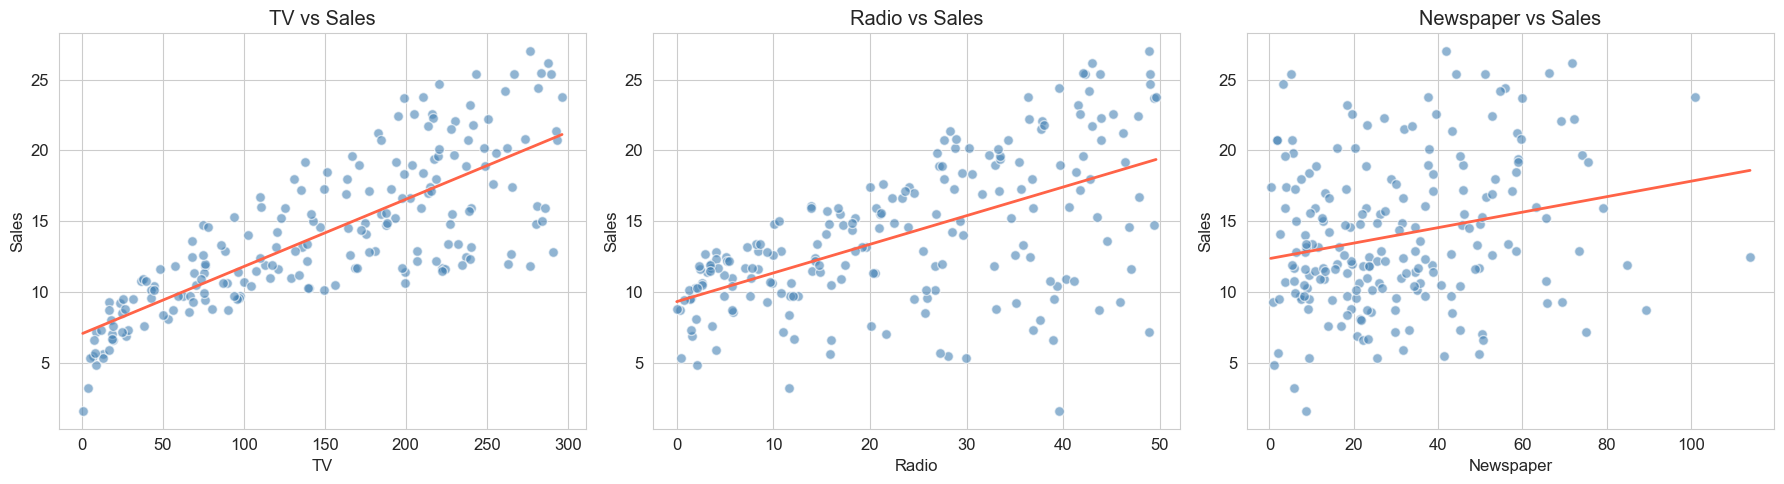

In [13]:
features = ['TV', 'Radio', 'Newspaper']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, feat in enumerate(features):
    axes[i].scatter(df[feat], df['Sales'], alpha=0.6, color='steelblue', edgecolors='white', s=50)
    # overlay a regression line
    z = np.polyfit(df[feat], df['Sales'], 1)
    p = np.poly1d(z)
    x_line = np.linspace(df[feat].min(), df[feat].max(), 100)
    axes[i].plot(x_line, p(x_line), color='tomato', linewidth=2)
    axes[i].set_xlabel(feat)
    axes[i].set_ylabel('Sales')
    axes[i].set_title(f'{feat} vs Sales')

plt.tight_layout()
plt.show()

Notice how TV shows a clear positive trend with Sales. Radio also trends upward, though with more scatter. Newspaper, on the other hand, shows very little linear relationship -- the points are essentially a cloud. This already hints that Newspaper might not be a strong predictor on its own.

### 4.4 Correlation matrix

The correlation matrix quantifies what the scatter plots showed qualitatively. A value close to +1 or -1 means a strong linear relationship; close to 0 means almost none.

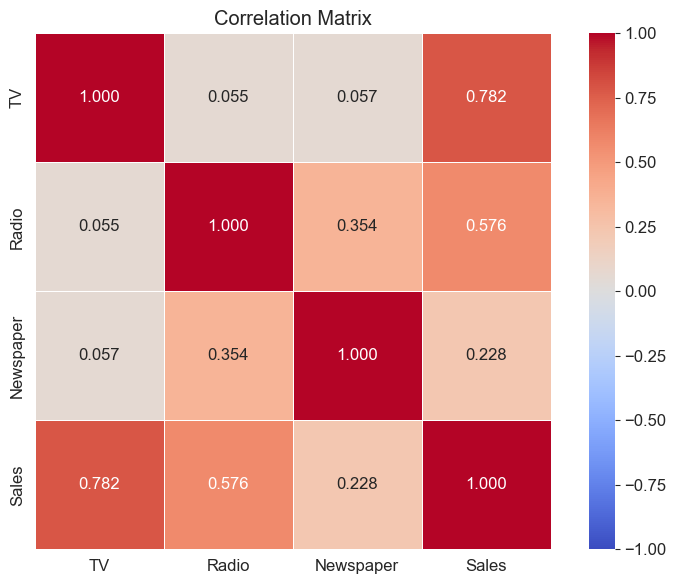

In [14]:
corr = df.corr().round(3)

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1,
            linewidths=0.5, fmt='.3f', square=True)
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

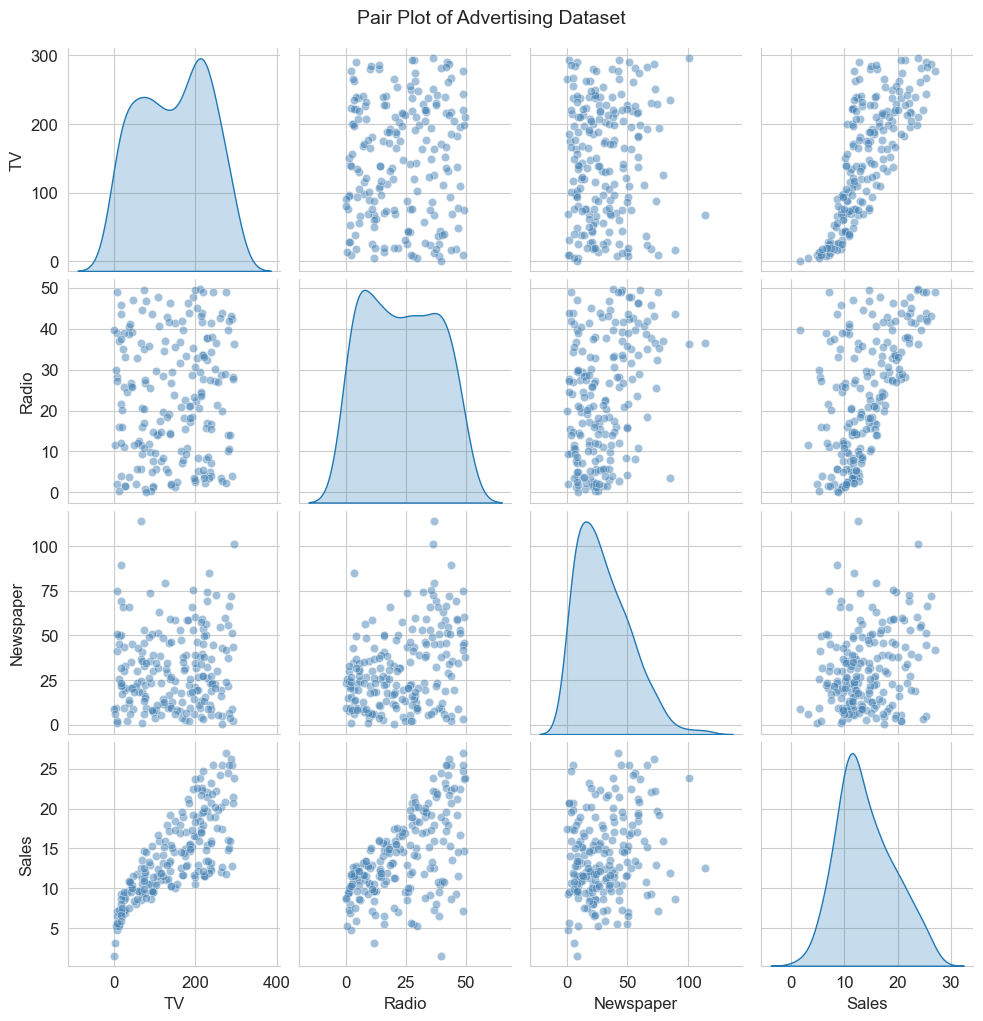

In [17]:
# pairplot for a comprehensive view of all bivariate relationships
sns.pairplot(df, diag_kind='kde', plot_kws={'alpha': 0.5, 'color': 'steelblue'})
plt.suptitle('Pair Plot of Advertising Dataset', y=1.02, fontsize=14)
plt.show()

## 5. Preparing the Data for Modelling

We will separate the features (X) from the target (y), then split into training and test sets. The training set is used to fit the model; the test set is held out so we can evaluate how well the model generalises to unseen data.

In [15]:
# define features and target
X = df[['TV', 'Radio', 'Newspaper']]
y = df['Sales']

# 70-30 train-test split with a fixed random state for reproducibility
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print(f"Training set size : {X_train.shape[0]} samples")
print(f"Test set size     : {X_test.shape[0]} samples")

Training set size : 140 samples
Test set size     : 60 samples


## 6. Building the Model

We will start with a **Simple Linear Regression** (using only TV, the strongest single predictor) and then move to **Multiple Linear Regression** (using all three features). Comparing the two will show how adding more predictors can improve -- or sometimes not improve -- the model.

### 6.1 Simple Linear Regression (TV only)

The equation we are fitting is:

$$\text{Sales} = \beta_0 + \beta_1 \times \text{TV}$$

where $\beta_0$ is the intercept (baseline sales when TV spend is zero) and $\beta_1$ is the slope (how much Sales change per unit increase in TV budget).

In [16]:
# simple linear regression using TV only
slr = LinearRegression()
slr.fit(X_train[['TV']], y_train)

print("--- Simple Linear Regression (TV only) ---")
print(f"Intercept (beta_0) : {slr.intercept_:.4f}")
print(f"Slope     (beta_1) : {slr.coef_[0]:.4f}")
print(f"\nEquation: Sales = {slr.intercept_:.4f} + {slr.coef_[0]:.4f} * TV")

--- Simple Linear Regression (TV only) ---
Intercept (beta_0) : 7.2395
Slope     (beta_1) : 0.0464

Equation: Sales = 7.2395 + 0.0464 * TV


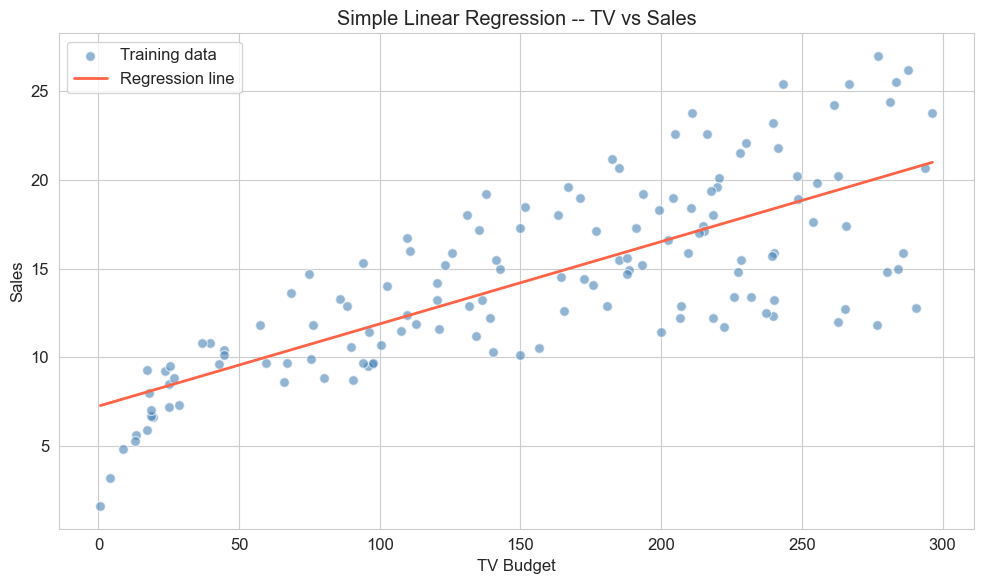

In [17]:
# visualise the simple regression line on the training data
plt.figure(figsize=(10, 6))
plt.scatter(X_train['TV'], y_train, alpha=0.6, color='steelblue', edgecolors='white', s=50, label='Training data')
x_range = np.linspace(X_train['TV'].min(), X_train['TV'].max(), 100).reshape(-1, 1)
plt.plot(x_range, slr.predict(x_range), color='tomato', linewidth=2, label='Regression line')
plt.xlabel('TV Budget')
plt.ylabel('Sales')
plt.title('Simple Linear Regression -- TV vs Sales')
plt.legend()
plt.tight_layout()
plt.show()

In [18]:
# evaluate the simple model on the test set
y_pred_slr = slr.predict(X_test[['TV']])

print("--- Simple LR -- Test set performance ---")
print(f"R-squared : {r2_score(y_test, y_pred_slr):.4f}")
print(f"MAE       : {mean_absolute_error(y_test, y_pred_slr):.4f}")
print(f"RMSE      : {np.sqrt(mean_squared_error(y_test, y_pred_slr)):.4f}")

--- Simple LR -- Test set performance ---
R-squared : 0.6714
MAE       : 2.2759
RMSE      : 2.9952


### 6.2 Multiple Linear Regression (TV + Radio + Newspaper)

Now we use all three features. The equation becomes:

$$\text{Sales} = \beta_0 + \beta_1 \times \text{TV} + \beta_2 \times \text{Radio} + \beta_3 \times \text{Newspaper}$$

This should capture more of the variance in Sales, especially since Radio also showed a meaningful correlation.

In [19]:
# multiple linear regression using all three features
mlr = LinearRegression()
mlr.fit(X_train, y_train)

print("--- Multiple Linear Regression ---")
print(f"Intercept : {mlr.intercept_:.4f}\n")
print("Coefficients:")
for feat, coef in zip(X.columns, mlr.coef_):
    print(f"  {feat:>10s} : {coef:.4f}")

print(f"\nEquation: Sales = {mlr.intercept_:.4f}", end="")
for feat, coef in zip(X.columns, mlr.coef_):
    sign = "+" if coef >= 0 else "-"
    print(f" {sign} {abs(coef):.4f} * {feat}", end="")
print()

--- Multiple Linear Regression ---
Intercept : 2.7089

Coefficients:
          TV : 0.0441
       Radio : 0.1993
   Newspaper : 0.0069

Equation: Sales = 2.7089 + 0.0441 * TV + 0.1993 * Radio + 0.0069 * Newspaper


## 7. Model Evaluation

We evaluate the multiple regression model on the held-out test set. The key metrics are:

- **R-squared** -- proportion of variance in Sales explained by the model (1.0 is perfect).
- **Mean Absolute Error (MAE)** -- average absolute difference between predicted and actual values.
- **Root Mean Squared Error (RMSE)** -- like MAE but penalises larger errors more heavily.

In [20]:
# predictions on test set
y_pred = mlr.predict(X_test)

r2   = r2_score(y_test, y_pred)
mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("--- Multiple LR -- Test set performance ---")
print(f"R-squared : {r2:.4f}")
print(f"MAE       : {mae:.4f}")
print(f"RMSE      : {rmse:.4f}")

# quick comparison table
print("\n--- Comparison: Simple vs Multiple LR ---")
comparison = pd.DataFrame({
    'Model': ['Simple (TV only)', 'Multiple (TV + Radio + Newspaper)'],
    'R2': [r2_score(y_test, y_pred_slr), r2],
    'MAE': [mean_absolute_error(y_test, y_pred_slr), mae],
    'RMSE': [np.sqrt(mean_squared_error(y_test, y_pred_slr)), rmse],
})
comparison = comparison.round(4)
print(comparison.to_string(index=False))

--- Multiple LR -- Test set performance ---
R-squared : 0.8609
MAE       : 1.5117
RMSE      : 1.9485

--- Comparison: Simple vs Multiple LR ---
                            Model     R2    MAE   RMSE
                 Simple (TV only) 0.6714 2.2759 2.9952
Multiple (TV + Radio + Newspaper) 0.8609 1.5117 1.9485


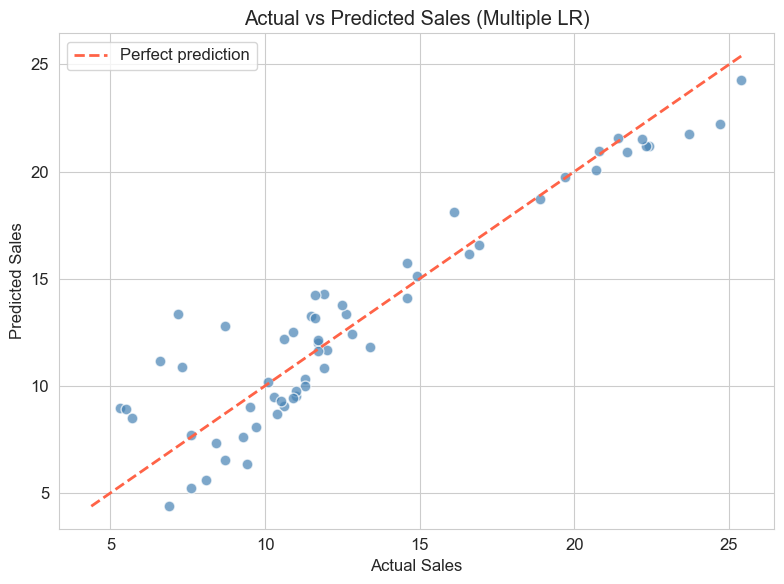

In [21]:
# actual vs predicted scatter
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.7, color='steelblue', edgecolors='white', s=60)
# perfect prediction line
mn, mx = min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())
plt.plot([mn, mx], [mn, mx], color='tomato', linewidth=2, linestyle='--', label='Perfect prediction')
plt.xlabel('Actual Sales')
plt.ylabel('Predicted Sales')
plt.title('Actual vs Predicted Sales (Multiple LR)')
plt.legend()
plt.tight_layout()
plt.show()

## 8. Residual Analysis

Residuals are the differences between actual and predicted values. For a well-behaved linear regression, we expect residuals to be:

1. **Normally distributed** (centered around zero)
2. **Homoscedastic** -- roughly constant variance across all predicted values
3. **Independent** -- no obvious pattern when plotted against fitted values

If these conditions are violated, the model's confidence intervals and p-values become unreliable, and we might need to rethink the approach.

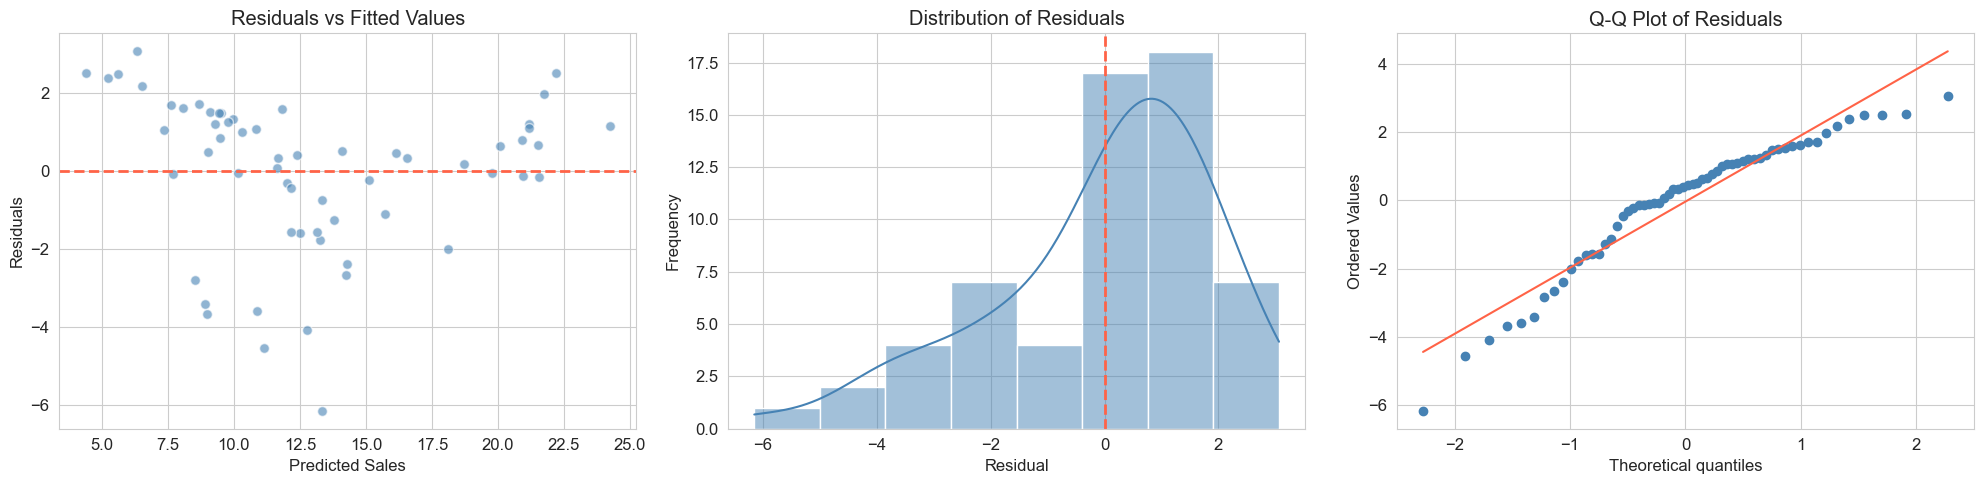

Shapiro-Wilk test: statistic = 0.9257, p-value = 0.0013
Result: Residuals deviate significantly from normality (p < 0.05).


In [22]:
residuals = y_test.values - y_pred

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# 1. residuals vs fitted values
axes[0].scatter(y_pred, residuals, alpha=0.6, color='steelblue', edgecolors='white', s=50)
axes[0].axhline(y=0, color='tomato', linewidth=2, linestyle='--')
axes[0].set_xlabel('Predicted Sales')
axes[0].set_ylabel('Residuals')
axes[0].set_title('Residuals vs Fitted Values')

# 2. histogram of residuals
sns.histplot(residuals, kde=True, ax=axes[1], color='steelblue', edgecolor='white')
axes[1].axvline(x=0, color='tomato', linewidth=2, linestyle='--')
axes[1].set_xlabel('Residual')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Distribution of Residuals')

# 3. Q-Q plot to check normality
stats.probplot(residuals, dist="norm", plot=axes[2])
axes[2].get_lines()[0].set_color('steelblue')
axes[2].get_lines()[1].set_color('tomato')
axes[2].set_title('Q-Q Plot of Residuals')

plt.tight_layout()
plt.show()

# formal normality test
stat, p_value = stats.shapiro(residuals)
print(f"Shapiro-Wilk test: statistic = {stat:.4f}, p-value = {p_value:.4f}")
if p_value > 0.05:
    print("Result: Cannot reject normality at the 5% level -- residuals look approximately normal.")
else:
    print("Result: Residuals deviate significantly from normality (p < 0.05).")

## 9. Interpreting the Coefficients

One of the biggest advantages of linear regression over more complex models is **interpretability**. Each coefficient tells us directly how a one-unit change in that feature is associated with a change in the target, holding everything else constant.

In [23]:
# build a tidy coefficient table
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': mlr.coef_,
})
coef_df.loc[len(coef_df)] = ['Intercept', mlr.intercept_]
coef_df = coef_df.sort_values('Coefficient', ascending=False).reset_index(drop=True)
coef_df['Coefficient'] = coef_df['Coefficient'].round(4)
print(coef_df.to_string(index=False))

  Feature  Coefficient
Intercept       2.7089
    Radio       0.1993
       TV       0.0441
Newspaper       0.0069


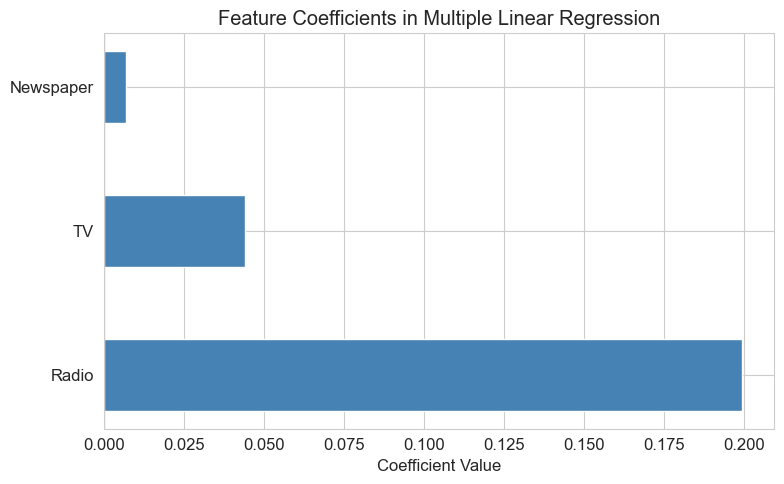

In [24]:
# coefficient bar chart
fig, ax = plt.subplots(figsize=(8, 5))
feature_coefs = coef_df[coef_df['Feature'] != 'Intercept'].copy()
colors = ['steelblue' if c >= 0 else 'lightcoral' for c in feature_coefs['Coefficient']]
ax.barh(feature_coefs['Feature'], feature_coefs['Coefficient'], color=colors, edgecolor='white', height=0.5)
ax.axvline(x=0, color='grey', linewidth=0.8)
ax.set_xlabel('Coefficient Value')
ax.set_title('Feature Coefficients in Multiple Linear Regression')
plt.tight_layout()
plt.show()

**How to read the coefficients:**

- **TV**: For every additional thousand dollars spent on TV advertising, Sales increase by roughly 0.05 thousand units (about 50 units), holding Radio and Newspaper constant.
- **Radio**: A stronger per-dollar effect -- each additional thousand dollars of Radio spending is associated with about 0.19 thousand units more in Sales.
- **Newspaper**: The coefficient is close to zero (and may even be slightly negative), confirming what we saw in the EDA. Newspaper advertising does not contribute meaningfully once TV and Radio are already in the model.

The intercept represents the expected Sales when all advertising budgets are zero -- a kind of baseline demand.

## 10. Summary

Here is what we went through:

| Step | What we did |
|------|------------|
| Data loading | Loaded the Advertising dataset (200 observations, 4 columns) |
| Data description | Checked types, missing values, and summary statistics |
| EDA | Histograms, boxplots, scatter plots, correlation matrix, pair plot |
| Simple LR | Built a model with TV alone -- decent but leaves variance on the table |
| Multiple LR | Added Radio and Newspaper -- significant improvement in R-squared |
| Evaluation | Compared R2, MAE, and RMSE across both models |
| Residuals | Checked normality, homoscedasticity, and independence of residuals |
| Interpretation | Read the coefficients to understand the business impact of each channel |

**Key takeaways:**
- TV is the single most important predictor, but Radio adds substantial value.
- Newspaper contributes very little once the other two are accounted for.
- The multiple regression model explains a large share of the variance in Sales.
- Residuals are reasonably well-behaved, which means the model's assumptions hold up here.

From a business perspective, a marketing team looking at this data would probably want to prioritise TV and Radio budgets and reconsider how much they invest in Newspaper advertising.